# Classical Baseline Model

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("../data/all_tracks_clean.csv")

df.head()

,genre,id,title,artist,album,duration_sec,rank,explicit,isrc,track_position,bpm,gain,contributors,num_contributors,tier
0,Pop,3602074142,Choosin' Texas,Ella Langley,Choosin' Texas,232,831096,False,USSM12504190,1,0.0,-8.3,Ella Langley (Main),1,9
1,Pop,3763842212,I Just Might,Bruno Mars,I Just Might,213,995346,False,USAT22509144,1,0.0,-10.4,Bruno Mars (Main),1,10
2,Pop,3503857201,Man I Need,Olivia Dean,Man I Need,184,991622,False,GBUM72503089,1,0.0,-8.7,Olivia Dean (Main),1,10
3,Pop,3881984641,American Girls,Harry Styles,"Kiss All The Time. Disco, Occasionally.",213,997062,False,USSM12600097,2,0.0,-8.3,Harry Styles (Main),1,10
4,Pop,3579685911,The Fate of Ophelia,Taylor Swift,The Life of a Showgirl,226,836426,False,USUG12506436,1,0.0,-8.5,Taylor Swift (Main),1,9


In [18]:
image_data = np.load("../data/spectrogram_tensors.npz")

X = image_data["X"]
indices = image_data["indices"]

In [19]:
y = df.iloc[indices]["tier"].values.astype(int)

In [20]:
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Unique tiers: {np.unique(y)}")

X shape: (7549, 1, 128, 128), y shape: (7549,)
Unique tiers: [ 1  2  3  4  5  6  7  8  9 10]


In [21]:
from sklearn.model_selection import train_test_split

# Flatten spectrograms: (N, 1, 128, 128) → (N, 16384)
X_flat = X.reshape(len(X), -1).astype(np.float32)

# Map tier labels to 0-indexed classes (tiers 1-10 → labels 0-9)
classes = np.unique(y)
label_map = {c: i for i, c in enumerate(sorted(classes))}
y_mapped = np.array([label_map[v] for v in y])

# 70/15/15 train/val/test split (same seed as CNN baseline)
X_train, X_temp, y_train, y_temp = train_test_split(X_flat, y_mapped, test_size=0.3, random_state=6500)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp,   test_size=0.5, random_state=6500)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (5284, 16384), Val: (1132, 16384), Test: (1133, 16384)


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize pixel values before PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# PCA: keep enough components to explain 95% of variance
pca = PCA(n_components=0.95, svd_solver="full", random_state=6500)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"PCA kept {pca.n_components_} components")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Train PCA shape: {X_train_pca.shape}")

PCA kept 2276 components
Explained variance: 0.9500
Train PCA shape: (5284, 2276)


In [24]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights to handle class imbalance (mirrors CNN baseline's class weighting)
sample_weights = compute_sample_weight("balanced", y_train)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    early_stopping_rounds=20,
    random_state=6500,
    n_jobs=-1,
)

xgb.fit(
    X_train_pca, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val_pca, y_val)],
    verbose=50,
)

print(f"\nBest iteration: {xgb.best_iteration}")

[0]	validation_0-mlogloss:2.29999
[50]	validation_0-mlogloss:2.25759
[83]	validation_0-mlogloss:2.26216

Best iteration: 63


Test Accuracy: 0.1483 | Test Ordinal MAE: 2.7132


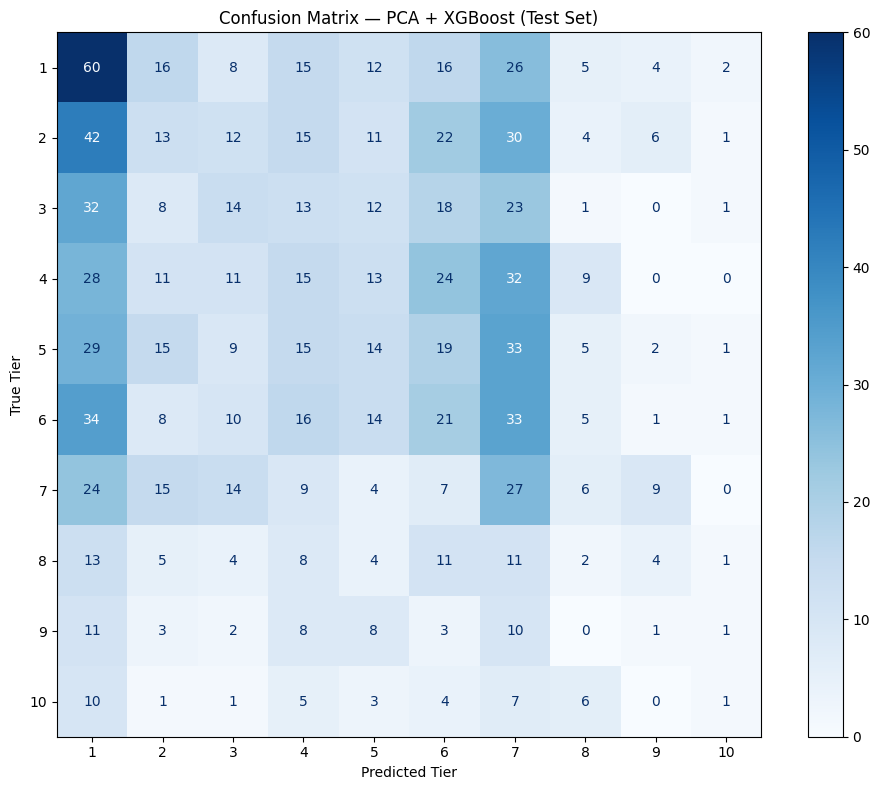

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = xgb.predict(X_test_pca)

acc = (y_pred == y_test).mean()
mae = np.abs(y_pred - y_test).mean()
print(f"Test Accuracy: {acc:.4f} | Test Ordinal MAE: {mae:.4f}")

tier_labels = [str(c) for c in sorted(classes)]
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tier_labels)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — PCA + XGBoost (Test Set)")
ax.set_xlabel("Predicted Tier")
ax.set_ylabel("True Tier")
plt.tight_layout()
plt.savefig("confusion_matrix_pca_xgb.png", dpi=150)
plt.show()